In [40]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

df = pd.read_csv("titanic.csv")

In [41]:
print(df.shape)
df.head()

(1000, 7)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,2,female,17.8,0,0,23.94
1,0,3,male,18.5,1,0,29.07
2,0,3,male,26.6,1,0,17.63
3,0,3,male,34.7,0,2,13.72
4,1,1,male,42.0,0,0,128.90


In [42]:
features = [
    "pclass", "sex_male", "age", "sibsp", "parch", "fare"
]
target = "survived"

In [43]:
print(df["Survived"].value_counts().to_dict())


{0: 560, 1: 440}


In [44]:
#fill Age based on the median age of passengers in the same Pclass and Sex group
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
print(df["Age"].isnull().sum())

# Fill missing Fare values with the median
df["Fare"] = df["Fare"].fillna(df["Fare"].median())




0


In [45]:
# Normalize column names
df.columns = df.columns.str.strip().str.lower()
# Create numeric sex_male feature
df["sex_male"] = (df["sex"] == "male").astype(int)


In [46]:
x = df[features].astype(float)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## TASK 01 — Bootstrap samples by hand

•	Use one random number generator, for example rng = np.random.default_rng(7).

In [47]:
def bootstrap_sample(X, y, rng):
    idx = rng.integers(0, len(X), len(X))
    return X.iloc[idx], y.iloc[idx]

rng = np.random.default_rng(7)

•	Draw one bootstrap sample from X_train and y_train.



In [48]:
idx = rng.integers(0, len(X_train), len(X_train))

# Create bootstrap sample
X_boot = X_train.iloc[idx]
y_boot = y_train.iloc[idx]


•	Report:
    o	original training-row count;

    o	bootstrap-row count;

    o	number of unique original rows represented at least once;

    o	number of rows that were never selected;

    o	one example row index selected more than once.


In [49]:

n_original = len(X_train)
n_bootstrap = len(X_boot)

unique_idx, counts = np.unique(idx, return_counts=True)

n_unique = len(unique_idx)
n_missing = n_original - n_unique

# Find an example row selected more than once
repeated_rows = unique_idx[counts > 1]

print("Original training-row count:", n_original)
print("Bootstrap-row count:", n_bootstrap)
print("Unique original rows represented:", n_unique)
print("Rows never selected:", n_missing)

if len(repeated_rows) > 0:
    example_idx = repeated_rows[0]
    example_count = counts[unique_idx == example_idx][0]

    print(
        f"Example row index selected more than once: "
        f"{example_idx} ({example_count} times)"
    )



Original training-row count: 800
Bootstrap-row count: 800
Unique original rows represented: 502
Rows never selected: 298
Example row index selected more than once: 2 (2 times)


•	Repeat the sampling 100 times. Plot a histogram of the proportion of unique rows in each bootstrap sample.

Average proportion of unique rows: 0.633


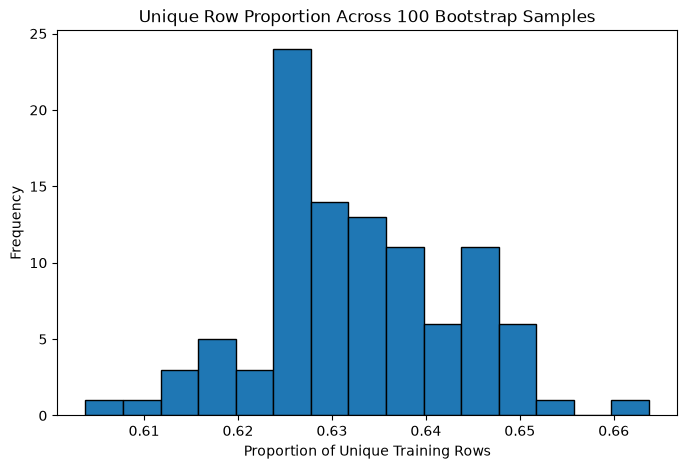

In [50]:
unique_proportions = []

for _ in range(100):
    idx = rng.integers(0, len(X_train), len(X_train))
    unique_count = len(np.unique(idx))
    proportion_unique = unique_count / len(X_train)
    unique_proportions.append(proportion_unique)

print(
    f"Average proportion of unique rows: "
    f"{np.mean(unique_proportions):.3f}"
)

plt.figure(figsize=(8, 5))

plt.hist(
    unique_proportions,
    bins=15,
    edgecolor="black"
)

plt.xlabel("Proportion of Unique Training Rows")
plt.ylabel("Frequency")
plt.title("Unique Row Proportion Across 100 Bootstrap Samples")

plt.show()


•	In a Markdown answer, explain why duplicates and missing rows are expected, not an error.

Bootstrap Sampling

    Same number of rows as the original dataset is selected.
    Rows are selected with replacement.
    Some rows can appear multiple times.
    Some rows may not be selected.
    This is expected and helps create different datasets for different trees.

## TASK 02 — Make five trees disagree

•	Use max_depth=5 so results remain readable.

•	Ask all five trees to predict the same first 20 test passengers.


In [51]:
rng = np.random.default_rng(0)
predictions = []
for i in range(5):
    X_boot, y_boot = bootstrap_sample(X_train, y_train, rng)
    tree = DecisionTreeClassifier(max_depth=5, random_state=i).fit(X_boot, y_boot)
    predictions.append(tree.predict(X_test.iloc[:20]))   # predict the same 20 test passengers

predictions = np.array(predictions)

print("Predictions of 5 trees for the same 20 test passengers:")
print(predictions)

Predictions of 5 trees for the same 20 test passengers:
[[1 1 0 0 1 1 1 1 0 0 0 0 0 0 1 0 0 0 0 1]
 [0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1]
 [0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 1 1 1 1 1 0 0 0 0 1 1 1 0 1 0 1]
 [0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1]]


•	Make a DataFrame with one row per passenger, one prediction column per tree, a vote count, the forest-style majority prediction, and the true label.

In [52]:
for i in range(20):
    votes = predictions[:, i]
    agree = len(set(votes)) == 1
    print(f"  passenger {i}: {votes}  {'(Agree)' if agree else '(Disagree)'}")


  passenger 0: [1 0 0 0 0]  (Disagree)
  passenger 1: [1 0 1 0 0]  (Disagree)
  passenger 2: [0 0 0 0 0]  (Agree)
  passenger 3: [0 0 0 0 0]  (Agree)
  passenger 4: [1 1 0 1 1]  (Disagree)
  passenger 5: [1 1 1 1 1]  (Agree)
  passenger 6: [1 0 0 1 0]  (Disagree)
  passenger 7: [1 1 1 1 1]  (Agree)
  passenger 8: [0 0 0 1 0]  (Disagree)
  passenger 9: [0 0 0 0 0]  (Agree)
  passenger 10: [0 0 0 0 0]  (Agree)
  passenger 11: [0 0 0 0 0]  (Agree)
  passenger 12: [0 0 0 0 0]  (Agree)
  passenger 13: [0 0 0 1 0]  (Disagree)
  passenger 14: [1 1 0 1 0]  (Disagree)
  passenger 15: [0 0 0 1 0]  (Disagree)
  passenger 16: [0 0 0 0 0]  (Agree)
  passenger 17: [0 0 0 1 0]  (Disagree)
  passenger 18: [0 0 0 0 0]  (Agree)
  passenger 19: [1 1 1 1 1]  (Agree)


•	Identify at least three passengers where the five trees disagree.

In [53]:
count = 0

for i in range(20):

    votes = predictions[:, i]

    if len(set(votes)) > 1:
        print(f"Passenger {i}: {votes}")
        count += 1     

Passenger 0: [1 0 0 0 0]
Passenger 1: [1 0 1 0 0]
Passenger 4: [1 1 0 1 1]
Passenger 6: [1 0 0 1 0]
Passenger 8: [0 0 0 1 0]
Passenger 13: [0 0 0 1 0]
Passenger 14: [1 1 0 1 0]
Passenger 15: [0 0 0 1 0]
Passenger 17: [0 0 0 1 0]


•	For each selected passenger, state the vote split, for example “3 survive / 2 do not survive.”

In [54]:
for i in range(20):
    votes = predictions[:, i]

    survive = np.sum(votes == 1)
    not_survive = np.sum(votes == 0)

    if survive > 0 and not_survive > 0:
        print(f"Passenger {i}: {survive} survive / {not_survive} do not survive")

Passenger 0: 1 survive / 4 do not survive
Passenger 1: 2 survive / 3 do not survive
Passenger 4: 4 survive / 1 do not survive
Passenger 6: 2 survive / 3 do not survive
Passenger 8: 1 survive / 4 do not survive
Passenger 13: 1 survive / 4 do not survive
Passenger 14: 3 survive / 2 do not survive
Passenger 15: 1 survive / 4 do not survive
Passenger 17: 1 survive / 4 do not survive


•	Calculate the percentage of these 20 passengers for whom there is disagreement.

In [55]:
disagreement_rate = np.mean([len(set(predictions[:, i])) > 1 for i in range(10)])
print(f"\nthe 5 trees disagree on {disagreement_rate:.0%} of these passengers")


the 5 trees disagree on 50% of these passengers


## TASK 03 — Implement a bagged forest manually

•	Train 100 depth-5 decision trees, each on a fresh bootstrap sample.

•	Store every tree in a list.


In [56]:
n_trees = 100
rng = np.random.default_rng(1)
trees = []

for i in range(n_trees):
    X_boot, y_boot = bootstrap_sample(X_train,y_train, rng)
    tree = DecisionTreeClassifier(max_depth=5, random_state=i).fit(X_boot,y_boot)
    trees.append(tree)


•	Collect class predictions and predicted survival probabilities from every tree on X_test.

In [57]:
all_predictions=np.array([tree.predict(X_test) for tree in trees])
all_probabilities = np.array([tree.predict_proba(X_test)[:,1]for tree in trees])


print("Class prediction shape:" ,all_predictions.shape)
print("Probability prediction shape:" ,all_probabilities.shape)

Class prediction shape: (100, 200)
Probability prediction shape: (100, 200)


•	Create:
    o	a majority-vote class prediction;
    o	an average survival probability;
    o	test accuracy and ROC-AUC.


In [58]:
forest_predictions = all_predictions.mean(axis=0).round().astype(int)
forest_probabilities = all_probabilities.mean(axis=0) 

accuracy = accuracy_score(y_test , forest_predictions)
roc_auc = roc_auc_score(y_test, forest_probabilities)

print(f"Accuracy:{accuracy:.3f}")
print(f"ROC_AUC:{roc_auc:.3f}")


Accuracy:0.715
ROC_AUC:0.811


•	Compare these against one single depth-5 tree trained on the full X_train.

In [59]:
single_tree_acc = accuracy_score(y_test, tree.predict(X_test))

print(f"Single Tree Accuracy: {single_tree_acc:.3f}")
print(f"100 Tree Accuracy: {accuracy:.3f}")

Single Tree Accuracy: 0.710
100 Tree Accuracy: 0.715


•	Plot a histogram of the 100 tree probabilities for one test passenger with a close vote (for example, average probability between 0.4 and 0.6).

Selected passenger: 1
Average survival probability: 0.442


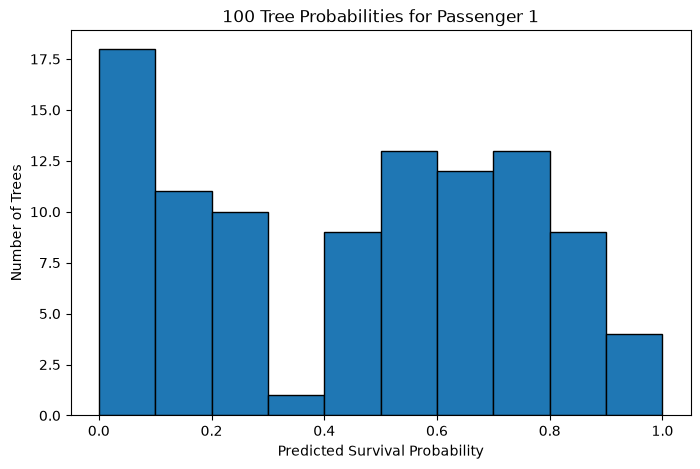

In [60]:
close_passengers = np.where(
    (forest_probabilities >= 0.4) &
    (forest_probabilities <= 0.6)
)[0]

# Select the first such passenger
passenger_idx = close_passengers[0]

# Get the 100 tree probabilities for that passenger
tree_probabilities = all_probabilities[:, passenger_idx]

print("Selected passenger:", passenger_idx)
print(f"Average survival probability: {tree_probabilities.mean():.3f}")

# Plot histogram
plt.figure(figsize=(8, 5))

plt.hist(
    tree_probabilities,
    bins=10,
    edgecolor="black"
)

plt.xlabel("Predicted Survival Probability")
plt.ylabel("Number of Trees")
plt.title(f"100 Tree Probabilities for Passenger {passenger_idx}")

plt.show()

## TASK 04 — Compare a tree, bagging, and a Random Forest

Train these three models with reproducible random states:

    Single tree	DecisionTreeClassifier(max_depth=5)
    Manual bagging	Your 100 depth-5 bootstrap trees
    Random Forest	RandomForestClassifier(n_estimators=200)


In [61]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)


tree_acc = accuracy_score(y_test, tree_model.predict(X_test))
tree_auc = roc_auc_score(y_test, tree_model.predict_proba(X_test)[:, 1])
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print(f"single decision tree:  accuracy={tree_acc:.4f}, AUC={tree_auc:.4f}")
print(f"random forest (200 trees): accuracy={rf_acc:.4f}, AUC={rf_auc:.4f}")

single decision tree:  accuracy=0.7150, AUC=0.7650
random forest (200 trees): accuracy=0.6850, AUC=0.7702


Then repeat the experiment across 25 fresh bootstrap samples of X_train/y_train. For each model, report mean test ROC-AUC and standard deviation of ROC-AUC. Use a bar chart with error bars.

In [62]:
tree_aucs, rf_aucs = [], []
for seed in range(25):
    rng = np.random.default_rng(seed)
    X_boot, y_boot = bootstrap_sample(X_train, y_train, rng)

    t = DecisionTreeClassifier(max_depth=5, random_state=seed).fit(X_boot, y_boot)
    r = RandomForestClassifier(n_estimators=200, random_state=seed).fit(X_boot, y_boot)

    tree_aucs.append(roc_auc_score(y_test, t.predict_proba(X_test)[:, 1]))
    rf_aucs.append(roc_auc_score(y_test, r.predict_proba(X_test)[:, 1]))

print(f"single tree AUC across 25 bootstrap training samples: mean={np.mean(tree_aucs):.4f}, std={np.std(tree_aucs):.4f}")
print(f"random forest AUC across 25 bootstrap training samples: mean={np.mean(rf_aucs):.4f}, std={np.std(rf_aucs):.4f}")
print("\nA lower standard deviation means the forest is less sensitive to training-data changes.")

single tree AUC across 25 bootstrap training samples: mean=0.7653, std=0.0175
random forest AUC across 25 bootstrap training samples: mean=0.7664, std=0.0143

A lower standard deviation means the forest is less sensitive to training-data changes.


## TASK 05 — Tune the two key Random Forest settings

1.	Sweep n_estimators over [10, 25, 50, 100, 200, 400] with oob_score=True.


In [63]:
print("n_estimators sweep:")

n_estimators_list = [10, 25, 50, 100, 200, 400]
oob_scores = []

for n_est in n_estimators_list:

    rf = RandomForestClassifier(
        n_estimators=n_est,
        oob_score=True,
        bootstrap=True,
        random_state=42
    ).fit(X_train, y_train)

    oob_scores.append(rf.oob_score_)

    print(f"  n_estimators={n_est:4}:  OOB accuracy = {rf.oob_score_:.4f}")

n_estimators sweep:
  n_estimators=  10:  OOB accuracy = 0.6863
  n_estimators=  25:  OOB accuracy = 0.6813


d:\CodeTrade\aiml-bootcamp-Krunalsinh\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


  n_estimators=  50:  OOB accuracy = 0.7100
  n_estimators= 100:  OOB accuracy = 0.7175
  n_estimators= 200:  OOB accuracy = 0.7175
  n_estimators= 400:  OOB accuracy = 0.7212


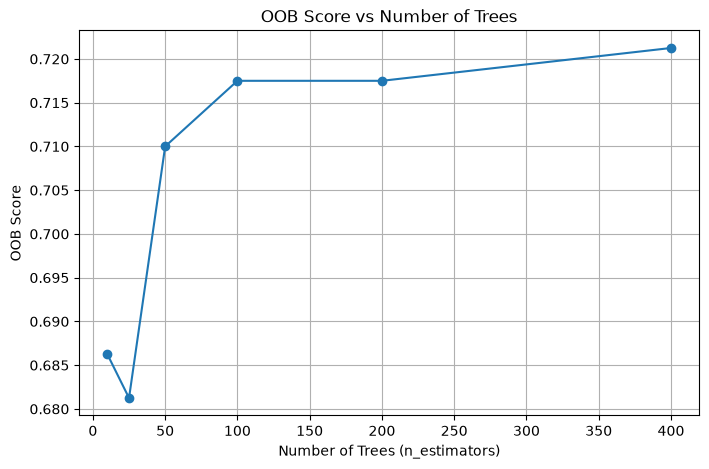

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(n_estimators_list, oob_scores, marker="o")

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("OOB Score")
plt.title("OOB Score vs Number of Trees")
plt.grid(True)

plt.show()

3.	Choose the smallest number of trees that is within 0.005 OOB accuracy of the best result. Explain why this is a sensible cost/performance choice.

In [65]:
best_oob = max(oob_scores)

for n, score in zip(n_estimators_list, oob_scores):
    if score >= best_oob - 0.005:
        selected_n_estimators = n
        break

print("Best OOB accuracy:", best_oob)
print("Selected number of trees:", selected_n_estimators)

Best OOB accuracy: 0.72125
Selected number of trees: 100


4.	With that number of trees, compare max_features values "sqrt", "log2", 0.5, and 1.0.

5.	Make a compact results table containing n_estimators, max_features, OOB score, test accuracy, and test ROC-AUC.


In [66]:
max_features_list = ["sqrt", "log2", 0.5, 1.0]

results = []

for max_features in max_features_list:

    rf = RandomForestClassifier(
        n_estimators=100,
        max_features=max_features,
        oob_score=True,
        bootstrap=True,
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1]

    results.append({
        "n_estimators": 100,
        "max_features": max_features,
        "OOB score": rf.oob_score_,
        "test accuracy": accuracy_score(y_test, y_pred),
        "test ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

   n_estimators max_features  OOB score  test accuracy  test ROC-AUC
0           100         sqrt     0.7175          0.680        0.7680
1           100         log2     0.7175          0.680        0.7680
2           100          0.5     0.7163          0.685        0.7775
3           100          1.0     0.7125          0.700        0.7749


6.	Select one final model. Evaluate it on the test set only once after making your selection.

In [67]:
best = results_df.loc[results_df["OOB score"].idxmax()]

final_model = RandomForestClassifier(
    n_estimators=100,
    max_features=best["max_features"],
    random_state=42,
    oob_score=True,
    bootstrap=True
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("Final model:", best["max_features"])
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))

Final model: sqrt
Test Accuracy: 0.68
Test ROC-AUC: 0.7680412371134021


## TASK 06 — Inspect OOB predictions and uncertainty

•	Inspect oob_decision_function_.


In [68]:
print("OOB decision function shape:", final_model.oob_decision_function_.shape)

print("\nFirst 5 OOB predictions:")
print(final_model.oob_decision_function_[:5])

OOB decision function shape: (800, 2)

First 5 OOB predictions:
[[0.90909091 0.09090909]
 [0.48275862 0.51724138]
 [0.09302326 0.90697674]
 [0.45945946 0.54054054]
 [0.6        0.4       ]]


•	Create a table of the ten training passengers whose OOB survival probability is closest to 0.5.

In [69]:
oob_prob = final_model.oob_decision_function_[:, 1]

closest = np.argsort(np.abs(oob_prob - 0.5))[:10]

oob_table = pd.DataFrame({
    "training_index": X_train.index[closest],
    "OOB survival probability": oob_prob[closest],
    "actual_survived": y_train.iloc[closest]
})

oob_table

,training_index,OOB survival probability,actual_survived
552,552,0.500000,0
853,853,0.500000,0
705,705,0.500000,1
895,895,0.500000,0
228,228,0.500000,0
594,594,0.500000,0
726,726,0.500000,0
808,808,0.500000,0
507,507,0.489796,0
640,640,0.511628,0


•	Show their relevant features, true label, and OOB probability.


In [70]:
oob_prob = final_model.oob_decision_function_[:, 1]

closest = np.argsort(np.abs(oob_prob - 0.5))[:10]

oob_table = X_train.iloc[closest].copy()

oob_table["true_label"] = y_train.iloc[closest].values
oob_table["OOB survival probability"] = oob_prob[closest]

oob_table

,pclass,sex_male,age,sibsp,parch,fare,true_label,OOB survival probability
552,3.0,1.0,13.6,0.0,0.0,11.99,0,0.500000
853,3.0,1.0,47.8,0.0,0.0,18.55,0,0.500000
705,3.0,0.0,24.0,0.0,0.0,5.07,1,0.500000
895,1.0,1.0,26.5,0.0,0.0,200.89,0,0.500000
228,3.0,1.0,10.7,0.0,2.0,16.62,0,0.500000
594,3.0,1.0,8.1,2.0,0.0,26.77,0,0.500000
726,1.0,1.0,38.7,0.0,2.0,204.18,0,0.500000
808,3.0,0.0,15.8,2.0,0.0,12.21,0,0.500000
507,3.0,1.0,32.3,1.0,1.0,16.61,0,0.489796
640,1.0,1.0,57.0,2.0,1.0,53.88,0,0.511628


#### •	Explain why a probability near 0.5 is an uncertain prediction.
#####  ==> A probability near 0.5 means the model is uncertain because the chances of both classes are almost equal. For example, a survival probability of 0.5 means the model sees roughly a 50% chance of survival and a 50% chance of not surviving.

####  •	Compare the final model’s OOB score with its held-out test accuracy. State whether they are close enough to give confidence, with a short reason.
##### ==> The final model has an OOB accuracy of 0.7175 and a test accuracy of 0.68. They are somewhat different (about 0.038 apart), so the OOB score gives some indication of performance, but not strong confidence that the held-out test performance will be the same.

## TASK 07 — Catch a misleading feature-importance result

In [71]:
rng = np.random.default_rng(2026)
X_train_noise = X_train.copy()
X_test_noise = X_test.copy()
X_train_noise["random_noise"] = rng.normal(size=len(X_train_noise))
X_test_noise["random_noise"] = rng.normal(size=len(X_test_noise))


•	Fit a 300-tree Random Forest using the noisy feature set.

In [72]:
rf_noisy = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_noise, y_train)

•	Create an impurity-importance ranking using .feature_importances_.

In [73]:
# how much each feature reduced impurity (Gini) across all splits in all trees
impurity_importance = pd.Series(
    rf_noisy.feature_importances_, index=X_train_noise.columns
).sort_values(ascending=False)

print("IMPURITY importance (built into every RandomForest, .feature_importances_):")
print(impurity_importance.round(4))
print(f"\n'random_noise' rank: {list(impurity_importance.index).index('random_noise') + 1} "
      f"out of {len(impurity_importance)} features")

IMPURITY importance (built into every RandomForest, .feature_importances_):
fare            0.2299
sex_male        0.2262
age             0.2077
random_noise    0.1954
pclass          0.0713
sibsp           0.0381
parch           0.0314
dtype: float64

'random_noise' rank: 4 out of 7 features


•	Create a permutation-importance ranking on X_test_noise using scoring="roc_auc", n_repeats=30, and a fixed random state.

In [74]:
perm_result = permutation_importance(
    rf_noisy, X_test_noise, y_test, n_repeats=20, random_state=42, scoring="roc_auc"
)
permutation_imp = pd.Series(
    perm_result.importances_mean, index=X_train_noise.columns
).sort_values(ascending=False)

print("PERMUTATION importance (shuffle-and-measure-the-damage):")
print(permutation_imp.round(4))
print(f"\n'random_noise' rank: {list(permutation_imp.index).index('random_noise') + 1} "
      f"out of {len(permutation_imp)} features")

PERMUTATION importance (shuffle-and-measure-the-damage):
sex_male        0.2042
pclass          0.0415
fare            0.0157
sibsp           0.0016
random_noise    0.0015
parch          -0.0028
age            -0.0054
dtype: float64

'random_noise' rank: 5 out of 7 features


•	Make side-by-side horizontal bar charts for the two rankings.

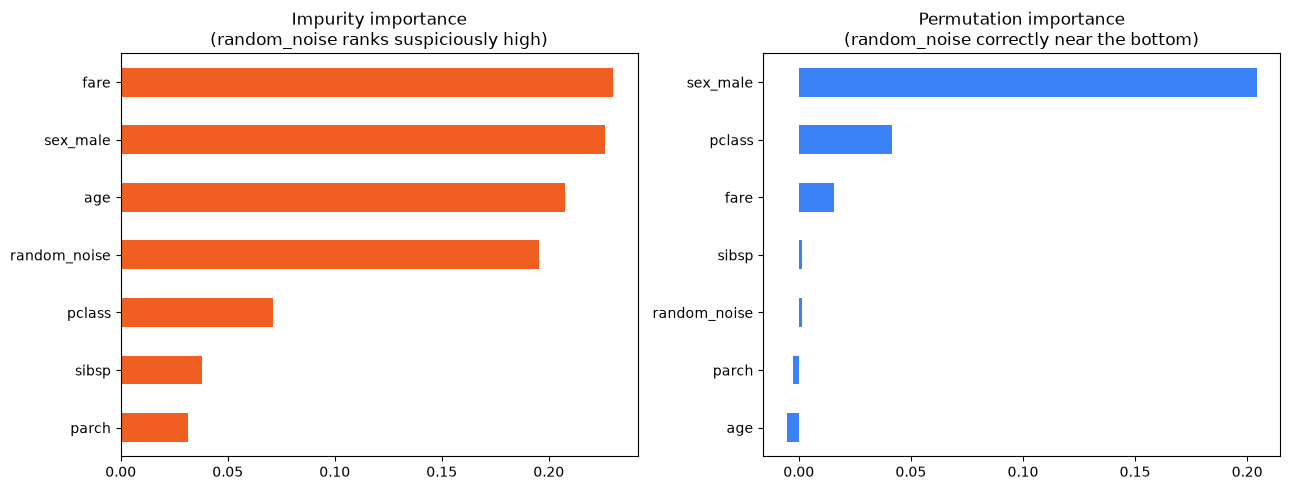

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

impurity_importance.plot(kind="barh", ax=axes[0], color="#F05E22")
axes[0].set_title("Impurity importance\n(random_noise ranks suspiciously high)")
axes[0].invert_yaxis()

permutation_imp.plot(kind="barh", ax=axes[1], color="#3B82F6")
axes[1].set_title("Permutation importance\n(random_noise correctly near the bottom)")
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

•	State the rank and score of random_noise in both methods.

In [76]:
print("Random Forest impurity importance:")
print(impurity_importance["random_noise"])

print("\nPermutation importance:")
print(permutation_imp["random_noise"])

Random Forest impurity importance:
0.19535309755882696

Permutation importance:
0.0015113602242017633


#### •	Write a short explanation of why the two methods may disagree.
##### ==> The two methods may disagree because they measure feature importance differently. Impurity importance looks at how much a feature helps split the decision trees, while permutation importance checks how much model performance decreases when the feature is shuffled. Therefore, a feature like `random_noise` can appear important in tree splits due to random correlations but have little real effect on predictions.




#### “For this dataset, I would not report impurity importance alone because random_noise received a surprisingly high impurity importance, while its permutation importance was near the bottom, showing that impurity importance can make a random feature appear more important than it actually is.”


## TASK 08 — Explain two model relationships with PDPs

•	For each graph, write 3–5 sentences that describe:

    o	the direction of the model’s average relationship;
    o	whether the effect is a jump, a curve, or a plateau;
    o	one reason it must not be treated as proof of causation.


•	Create a PDP for sex_male.

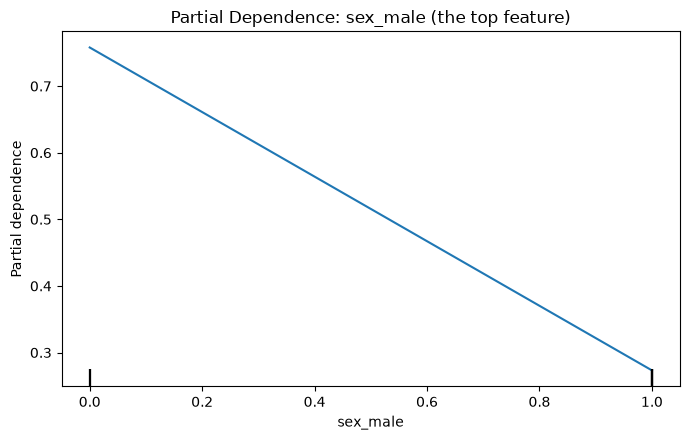

In [78]:

rf_clean = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(7, 4.5))
PartialDependenceDisplay.from_estimator(rf_clean, X_train, ["sex_male"], ax=ax)
ax.set_title("Partial Dependence: sex_male (the top feature)")
plt.tight_layout(); plt.show()

### For graph of PDP(sex_Male)

#### ==> Direction: Negative — predicted survival probability decreases as sex_male changes from 0 to 1.
#### ==> Shape: Smooth downward trend, not a sudden jump or plateau.
#### ==> Meaning: The model predicts higher average survival probability for sex_male = 0 than for sex_male = 1

•	Create a PDP for fare.

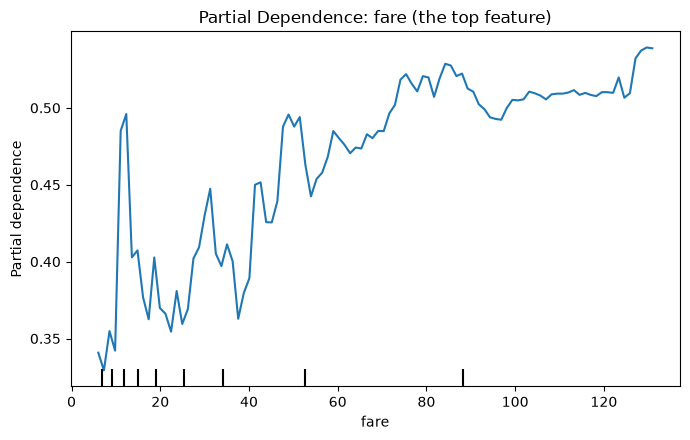

In [81]:
fig, ax = plt.subplots(figsize=(7, 4.5))
PartialDependenceDisplay.from_estimator(rf_clean, X_train, ["fare"], ax=ax)
ax.set_title("Partial Dependence: fare (the top feature)")
plt.tight_layout(); plt.show()

### For graph of PDP(fare)

#### ==> Direction: Generally positive — predicted survival probability increases as fare increases.
#### ==> Shape: Gradual upward curve with some small fluctuations.
#### ==> Meaning: The model generally associates higher fares with higher predicted survival probability.

### •	Include one brief caution about correlated features and unrealistic feature combinations.
#### ==> * **Caution:** PDP can be misleading when features are correlated or when it evaluates unrealistic combinations of feature values that rarely occur in the actual dataset.
